# GPT-4 Automated Essay Scorer  
### with Few-Shot Calibration from Real Examples

This notebook scores student essays using GPT-4 calibrated with **real labelled examples** (one per score level, 1–6) to fix the calibration bias that caused GPT-4 to never award scores above 4.

**Three fixes applied vs. the previous version:**
1. **Few-shot examples** — one real essay per score level shown to GPT-4 before grading
2. **Rate-limit handling** — workers reduced + longer backoff + per-minute throttling
3. **Per-dimension rubric** — separate anchors for each sub-score to break the clustering problem

---

## 2. Imports

In [1]:
import os, re, json, time, concurrent.futures
from pathlib import Path
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from tqdm.notebook import tqdm

load_dotenv()   # reads OPENAI_API_KEY from .env in the same folder
print('Imports OK')

Imports OK


## 3. Configuration

Only `API_KEY`, `TEST_CSV`, and optionally `MODEL` need editing.

In [5]:
BASE      = Path(r"C:/Users/anand/Documents/Automated_essay_scoring")
RAW       = BASE / "data" / "raw"
PROCESSED = BASE / "data" / "processed"
EXPORT    = BASE / "data" / "model"

OUTPUT   = 'test_predictions_gpt4.csv'   # competition submission file
DETAIL   = 'test_predictions_gpt4_detailed.csv'  # detailed sub-scores file

TRAIN_FILE = RAW / "train.csv"
PRED_FILE  = PROCESSED / "test_predictions_gpt4.csv"
PRED_DETAIL_FILE  = PROCESSED / "test_predictions_gpt4_detailed.csv"

In [7]:
API_KEY  = os.environ.get('OPENAI_API_KEY')

MODEL    = 'gpt-4o'   # 'gpt-4o-mini' for cheap test runs
WORKERS  = 2          # keep low (2) to avoid TPM rate limits
RETRIES  = 5          # more retries for rate-limit recovery
BACKOFF  = 4.0        # longer wait between retries

print(f'Model   : {MODEL}')
print(f'Workers : {WORKERS}')
print(f'Key set : {bool(API_KEY and not API_KEY.startswith("sk-YOUR"))}')
print(f'CSV     : {Path(TRAIN_FILE).exists()}')

Model   : gpt-4o
Workers : 2
Key set : True
CSV     : True


## 4. Few-Shot Examples

These are **real student essays** with their verified scores (loaded from `examples.xlsx`).  
Including one example per score level tells GPT-4 exactly what a 1, 2, 3, 4, 5, and 6 look like in *this* dataset, fixing the calibration problem where GPT-4 never awarded scores above 4.

In [9]:
# One real essay per score level — embedded directly from examples.xlsx
# Keys are the score (1-6), values are truncated essay excerpts.
FEW_SHOT_ESSAYS = {
    1: ("The face that is shown isnt from any aliens ,we have no kind of proof that really tells us that the face piece is by an alien. The piece thatwas spotted was shadowy so it could of been mess with to look like that, instead it could of look clear and smooth but when they touck the face it looked like if there was a shadow .The piece looked if it was during a war Many places that went to go see what the face was made of an airplane,some sent there space robots but they got unclear information .many thought there was life on mars back then so thats hopw the face appear .no one really knows how the face was made. Skeptics thpought the alien marking was covered up by haze so if that was true no on......"),
    2: ("In order to detect human emotions these students are saying thrie computer can do it. I dont believe this and i'\''ll tell you why. Computers can tell you how u fell on the outside but can'\''t tell you about the inside. Emotions are not based on facial expressions. I can smile through pain but the computer won'\''t tell you that. Many people cause decive you with there emotions. The person who created this only uses six basic emotions that can decive you on the outside. Explaining human emotions are very difficult because you cant actually tell how they feel on the inside. The emotions the show on the outside could decive how you see things. You should take the time to ask the person how they really......"),
    3: ("Countries have started to limit the usage of cars. the limitation of cars can be very benifitial. evidence from the articles can show that limiting cars can benifit us citizens. Their advantages to limiting car usage. For example, evidence from the article says \"Vauban'\''s streets are completely \"car-free\"-except the main thoroughfare, where the tran to downtown freiburg runs, and a few streets on one edge of the cummunity\". this shows you that if people are willing to give up their cars it can benifit the cummunity. Information from the article shows \"On Monday motorist with even-license plates were ordered to leave their cars at home or suffer a 22-euro fine\". Limiting car usage can really h......"),
    4: ("Google field-tested a driverless car that drove five hundred miles with only one accident, which was when a human was driving the car. Driverless cars are hardly a new idea, but recently in the 21st century, it has become more and more of a reality. Ever since 2009 \"Google has had cars that could drive independently under specific conditions\" (Author). Driverless cars haven'\''t been perfected yet and still rely on human assitance now and then, but with a few more years of research they could mass-produced. Driverless cars should be used to replace current cars, trucks, and buses. They could be used like taxis and would use half as less fuel than what current taxis use. Additionaly, they are mo......"),
    5: ("What would you do if you saw a picture of a human face on the ground of another planet? If you were like millions of Americans in the world in 1976 you would automatically assume the worse. That it was some type of communication from aliens or that it was a warning that aliens from Mars were going to come to Earth. In the end these people where wrong and started to commonly be reffered to as conspiracy theorists. The human faces of Mars are really just natural landforms and NASA has been proving that for years. If you were one of the people told to discover the truth about the faces would you stay calm, or buckle under the pressure? Many people in NASA stayed calm and put together compelling......"),
    6: ("Within Nick D'\''Altos article \"Making Mona Lisa Smile\", Nick helps me view the value of using technology to read ones emotional expressions. The use of technology to read the emotional expressions of a student within a classroom or ones facial expressions throughout a painting can help distinguish how one had felt. Technology can be used for many things and now those from the Facial Action Coding System has been using this new technology to read the expression given off of Leonardo da Vinci'\''s Renaissance painting, Mona Lisa. D'\''Alto helps put reasonings behind his new Facial Action COding Sytem by promising applications throughout yourself and throughout those in famous paintings. When reading ......")
}

print('Few-shot examples loaded:')
for s, t in FEW_SHOT_ESSAYS.items():
    print(f'  Score {s}: {len(t)} chars — {t[:80]}...')

Few-shot examples loaded:
  Score 1: 706 chars — The face that is shown isnt from any aliens ,we have no kind of proof that reall...
  Score 2: 712 chars — In order to detect human emotions these students are saying thrie computer can d...
  Score 3: 708 chars — Countries have started to limit the usage of cars. the limitation of cars can be...
  Score 4: 708 chars — Google field-tested a driverless car that drove five hundred miles with only one...
  Score 5: 706 chars — What would you do if you saw a picture of a human face on the ground of another ...
  Score 6: 712 chars — Within Nick D'''Altos article "Making Mona Lisa Smile", Nick helps me view the v...


## 5. Rubric & System Prompt

Key improvements over v1:
- Explicitly tells GPT-4 it is grading **student essays**, not professional writing
- Each sub-dimension has its own scoring anchors (fixes sub-score clustering)
- Six few-shot examples are injected so GPT-4 is calibrated to this dataset's standards

In [10]:
RUBRIC = """
Score 6: Clear mastery with few errors, outstanding critical thinking, appropriate evidence, well-organized, skilled language use.
Score 5: Reasonable mastery with occasional errors, strong critical thinking, generally appropriate evidence, well-organized, good language use.
Score 4: Adequate mastery with some lapses, competent critical thinking, adequate evidence, generally organized, fair language use.
Score 3: Developing mastery with weaknesses, limited critical thinking, inconsistent evidence, limited organization, fair language use with weaknesses.
Score 2: Little mastery with serious flaws, weak critical thinking, insufficient evidence, poor organization, limited language use with frequent errors.
Score 1: Very little or no mastery, severely flawed, no viable point of view, disorganized, fundamental language flaws, pervasive grammar/mechanics errors.
""".strip()

DIMENSION_RUBRIC = """
MASTERY (grammar, mechanics, spelling):
  6=virtually no errors | 5=occasional minor errors | 4=some lapses | 3=noticeable weaknesses | 2=frequent errors | 1=pervasive errors throughout

CRITICAL THINKING (argument quality, point of view):
  6=outstanding, nuanced argument | 5=strong | 4=competent | 3=limited/underdeveloped | 2=weak | 1=no viable point of view

EVIDENCE (use of supporting details/examples):
  6=appropriate, well-integrated | 5=generally appropriate | 4=adequate | 3=inconsistent | 2=insufficient | 1=absent or irrelevant

ORGANISATION (structure, flow, paragraphing):
  6=well-organised, clear flow | 5=well-organised | 4=generally organised | 3=limited organisation | 2=poor | 1=disorganised

LANGUAGE USE (vocabulary, style, sentence variety):
  6=skilled, varied | 5=good | 4=fair | 3=fair with weaknesses | 2=limited | 1=fundamental flaws
""".strip()

# Build few-shot block from the real examples
def build_few_shot_block():
    lines = []
    lines.append('CALIBRATION EXAMPLES (real student essays from this dataset):')
    lines.append('Study these carefully to understand the scoring standard.\n')
    for score in range(1, 7):
        lines.append(f'--- Score {score} Example ---')
        lines.append(FEW_SHOT_ESSAYS[score][:500])
        lines.append(f'→ This essay scores {score}/6\n')
    return '\n'.join(lines)

SYSTEM_PROMPT = f"""You are an expert grader of student argumentative essays.
You are grading essays written by students under TIMED EXAM CONDITIONS.
Grade relative to other students — NOT compared to professional or published writing.
A score of 5 or 6 should be awarded to essays that are strong FOR A STUDENT.

OVERALL RUBRIC:
{RUBRIC}

{DIMENSION_RUBRIC}

{build_few_shot_block()}

Return your answer in EXACTLY this JSON format and nothing else:
{{
  \"mastery_score\":      <1-6>,
  \"critical_thinking\":  <1-6>,
  \"evidence\":           <1-6>,
  \"organisation\":       <1-6>,
  \"language_use\":       <1-6>,
  \"overall_score\":      <1-6>,
  \"justification\":      \"<one sentence explaining the overall score>\"
}}

overall_score must be 1-6 matching the rubric. Do NOT output anything outside the JSON.
"""

print(f"System prompt length: {len(SYSTEM_PROMPT):,} chars")
print("\nFirst 500 chars:")
print(SYSTEM_PROMPT[:500])

System prompt length: 5,881 chars

First 500 chars:
You are an expert grader of student argumentative essays.
You are grading essays written by students under TIMED EXAM CONDITIONS.
Grade relative to other students — NOT compared to professional or published writing.
A score of 5 or 6 should be awarded to essays that are strong FOR A STUDENT.

OVERALL RUBRIC:
Score 6: Clear mastery with few errors, outstanding critical thinking, appropriate evidence, well-organized, skilled language use.
Score 5: Reasonable mastery with occasional errors, strong 


## 6. Helper Functions

In [11]:
def build_user_prompt(essay_text: str) -> str:
    return f'Please grade the following student essay:\n\n{essay_text}'


def parse_gpt_response(response_text: str) -> dict:
    cleaned = re.sub(r'```(?:json)?', '', response_text).strip().rstrip('`').strip()
    data = json.loads(cleaned)
    required = ['mastery_score','critical_thinking','evidence',
                'organisation','language_use','overall_score','justification']
    for key in required:
        if key not in data:
            raise ValueError(f'Missing key: {key}')
    overall = int(data['overall_score'])
    if not (1 <= overall <= 6):
        raise ValueError(f'overall_score {overall} out of range 1-6')
    return data


def score_essay(essay_id: str, essay_text: str, client: OpenAI) -> dict:
    for attempt in range(1, RETRIES + 1):
        try:
            completion = client.chat.completions.create(
                model=MODEL,
                temperature=0,
                max_tokens=400,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': build_user_prompt(essay_text)},
                ],
            )
            raw = completion.choices[0].message.content.strip()
            result = parse_gpt_response(raw)
            result['essay_id'] = essay_id
            return result
        except Exception as exc:
            is_rate_limit = '429' in str(exc) or 'rate_limit' in str(exc).lower()
            wait = BACKOFF ** attempt if is_rate_limit else BACKOFF
            if attempt == RETRIES:
                print(f'[ERROR] {essay_id}: {exc}')
                return {
                    'essay_id': essay_id,
                    'mastery_score': None, 'critical_thinking': None,
                    'evidence': None,      'organisation': None,
                    'language_use': None,  'overall_score': None,
                    'justification': f'ERROR: {exc}',
                }
            print(f'  Attempt {attempt} failed for {essay_id} — retrying in {wait:.1f}s...')
            time.sleep(wait)

print('Helper functions ready.')

Helper functions ready.


## 7. Load Test Data

In [15]:
df = pd.read_csv(TRAIN_FILE)

df_original = df.copy()

df.head()

,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3


In [16]:
df = df.drop('score', axis=1 ).iloc[:500]

df.head()

,essay_id,full_text
0,000d118,Many people have car where they live. The thin...
1,000fe60,I am a scientist at NASA that is discussing th...
2,001ab80,People always wish they had the same technolog...
3,001bdc0,"We all heard about Venus, the planet without a..."
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg..."


In [17]:
len(df)

500

In [18]:
assert {'essay_id','full_text'}.issubset(df.columns), (
    f'CSV must have essay_id and full_text columns. Found: {list(df.columns)}'
)
print(f'Loaded {len(df):,} essays')
display(df.head(3))

Loaded 500 essays


,essay_id,full_text
0,000d118,Many people have car where they live. The thin...
1,000fe60,I am a scientist at NASA that is discussing th...
2,001ab80,People always wish they had the same technolog...


## 8. (Optional) Sanity Check — Score One Essay

Run this before scoring all essays to verify the API key works and the prompt is returning valid scores across the full 1–6 range.

In [19]:
client_test = OpenAI(api_key=API_KEY)
sample = df.iloc[0]
result = score_essay(sample['essay_id'], sample['full_text'], client_test)
print(json.dumps(result, indent=2))

{
  "mastery_score": 2,
  "critical_thinking": 3,
  "evidence": 3,
  "organisation": 2,
  "language_use": 2,
  "overall_score": 2,
  "justification": "The essay presents a basic argument about car-free living with some supporting evidence, but it suffers from frequent grammatical errors, poor organization, and limited language use.",
  "essay_id": "000d118"
}


## 9. Score All Essays

> **Rate limit note:** If you're on a free/tier-1 OpenAI account (TPM limit = 30,000), keep `WORKERS = 1` or `2`. Increase only if your account has a higher token-per-minute limit.

> **Cost:** ~\$0.005/essay with `gpt-4o` → ~\$85 for 17k essays. Use `gpt-4o-mini` (~\$0.0003/essay) to test on a subset first.

In [20]:
client = OpenAI(api_key=API_KEY)
essays = list(zip(df['essay_id'], df['full_text']))
results = []

def _score(args):
    eid, text = args
    return score_essay(eid, text, client)

with concurrent.futures.ThreadPoolExecutor(max_workers=WORKERS) as executor:
    futures = {executor.submit(_score, e): e[0] for e in essays}
    for future in tqdm(
        concurrent.futures.as_completed(futures),
        total=len(futures),
        desc='Scoring essays',
    ):
        results.append(future.result())

print(f'Done — {len(results):,} results.')

Scoring essays:   0%|          | 0/500 [00:00<?, ?it/s]

  Attempt 1 failed for 0081f18 — retrying in 4.0s...
  Attempt 1 failed for 0098ef4 — retrying in 4.0s...
  Attempt 1 failed for 00a6693 — retrying in 4.0s...
  Attempt 1 failed for 00b3311 — retrying in 4.0s...
  Attempt 1 failed for 00ccc2d — retrying in 4.0s...
  Attempt 1 failed for 00ef89f — retrying in 4.0s...
  Attempt 1 failed for 00eabc5 — retrying in 4.0s...
  Attempt 1 failed for 00f6ac7 — retrying in 4.0s...
  Attempt 1 failed for 0123792 — retrying in 4.0s...
  Attempt 1 failed for 013ac83 — retrying in 4.0s...
  Attempt 2 failed for 013ac83 — retrying in 16.0s...
  Attempt 1 failed for 01711c3 — retrying in 4.0s...
  Attempt 1 failed for 018ff85 — retrying in 4.0s...
  Attempt 1 failed for 01b55c8 — retrying in 4.0s...
  Attempt 2 failed for 01b55c8 — retrying in 16.0s...
  Attempt 3 failed for 01b55c8 — retrying in 64.0s...
  Attempt 1 failed for 0224c63 — retrying in 4.0s...
  Attempt 1 failed for 0227e67 — retrying in 4.0s...
  Attempt 2 failed for 0227e67 — retrying i

## 10. Build Results DataFrame

In [21]:
results_df = pd.DataFrame(results)
merged = df[['essay_id']].merge(results_df, on='essay_id', how='left')
merged = merged.rename(columns={'overall_score': 'score'})
merged['score'] = pd.to_numeric(merged['score'], errors='coerce').fillna(0).astype(int)

print(f'Shape: {merged.shape}')
display(merged.head())

Shape: (500, 8)


,essay_id,mastery_score,critical_thinking,evidence,organisation,language_use,score,justification
0,000d118,2.0,3.0,3.0,2.0,2.0,2,The essay demonstrates limited mastery with fr...
1,000fe60,3.0,3.0,3.0,3.0,3.0,3,The essay presents a limited argument with som...
2,001ab80,4.0,4.0,4.0,4.0,4.0,4,The essay presents a competent argument agains...
3,001bdc0,3.0,4.0,4.0,3.0,3.0,3,The essay demonstrates developing mastery with...
4,002ba53,3.0,3.0,3.0,3.0,3.0,3,The essay demonstrates developing mastery with...


## 11. Save Output Files

In [22]:
merged.to_csv(DETAIL, index=False)
print(f'Detailed CSV → {DETAIL}')

submission = merged[['essay_id','score']].copy()
submission.to_csv(OUTPUT, index=False)
print(f'Submission CSV → {OUTPUT}')
display(submission.head())

Detailed CSV → test_predictions_gpt4_detailed.csv
Submission CSV → test_predictions_gpt4.csv


,essay_id,score
0,000d118,2
1,000fe60,3
2,001ab80,4
3,001bdc0,3
4,002ba53,3


## 12. Summary Statistics

In [23]:
valid  = merged[merged['score'].between(1,6)]
failed = merged[~merged['score'].between(1,6)]

print(f'Total   : {len(merged):,}')
print(f'Scored  : {len(valid):,}')
print(f'Failed  : {len(failed):,}')

print('\nScore distribution:')
dist = valid['score'].value_counts().sort_index()
for s, c in dist.items():
    bar = '█' * int(c/len(valid)*40)
    print(f'  {s}  {bar} {c:,} ({c/len(valid)*100:.1f}%)')

print(f'\nMean  : {valid["score"].mean():.2f}')
print(f'Std   : {valid["score"].std():.2f}')

Total   : 500
Scored  : 499
Failed  : 1

Score distribution:
  1   2 (0.4%)
  2  ████ 58 (11.6%)
  3  ████████████████████████ 303 (60.7%)
  4  ██████████ 125 (25.1%)
  5   11 (2.2%)

Mean  : 3.17
Std   : 0.67


## 13. Visualisations

C:\Users\anand\AppData\Local\Temp\ipykernel_13304\397606183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid[col] = pd.to_numeric(valid[col], errors='coerce')


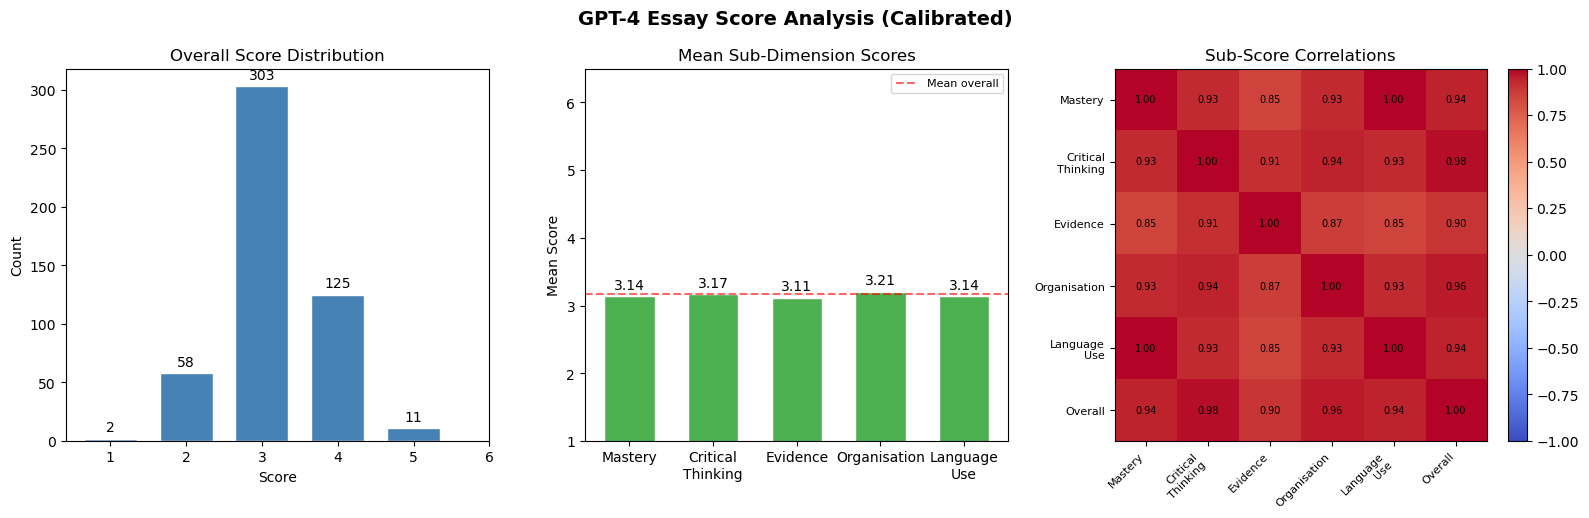

Saved → gpt4_score_analysis.png


In [24]:
sub_cols   = ['mastery_score','critical_thinking','evidence','organisation','language_use']
sub_labels = ['Mastery','Critical\nThinking','Evidence','Organisation','Language\nUse']

if len(valid) == 0:
    print('No valid scores to plot.')
else:
    for col in sub_cols:
        valid[col] = pd.to_numeric(valid[col], errors='coerce')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('GPT-4 Essay Score Analysis (Calibrated)', fontsize=14, fontweight='bold')

    # Score distribution
    ax = axes[0]
    dist = valid['score'].value_counts().sort_index()
    bars = ax.bar(dist.index, dist.values, color='steelblue', edgecolor='white', width=0.7)
    ax.bar_label(bars, padding=3)
    ax.set_xlabel('Score'); ax.set_ylabel('Count')
    ax.set_title('Overall Score Distribution')
    ax.set_xticks(range(1, 7))

    # Sub-score means
    ax2 = axes[1]
    means = valid[sub_cols].mean()
    bars2 = ax2.bar(sub_labels, means, color='#4CAF50', edgecolor='white', width=0.6)
    ax2.bar_label(bars2, fmt='%.2f', padding=3)
    ax2.set_ylim(1, 6.5)
    ax2.set_ylabel('Mean Score')
    ax2.set_title('Mean Sub-Dimension Scores')
    ax2.axhline(valid['score'].mean(), color='red', linestyle='--', alpha=0.6, label='Mean overall')
    ax2.legend(fontsize=8)

    # Correlation heatmap
    ax3 = axes[2]
    heat_cols   = sub_cols + ['score']
    heat_labels = sub_labels + ['Overall']
    corr = valid[heat_cols].corr()
    im = ax3.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax3.set_xticks(range(len(heat_labels))); ax3.set_xticklabels(heat_labels, rotation=45, ha='right', fontsize=8)
    ax3.set_yticks(range(len(heat_labels))); ax3.set_yticklabels(heat_labels, fontsize=8)
    for i in range(len(heat_labels)):
        for j in range(len(heat_labels)):
            ax3.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax3, fraction=0.046)
    ax3.set_title('Sub-Score Correlations')

    plt.tight_layout()
    plt.savefig('gpt4_score_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → gpt4_score_analysis.png')

## 14. Sample Justifications

In [25]:
sample_n = min(5, len(valid))
for _, row in valid.sample(sample_n, random_state=42).iterrows():
    print(f'essay_id : {row["essay_id"]}')
    print(f'Score    : {row["score"]}')
    print(f'Reason   : {row["justification"]}')
    print('-'*70)

essay_id : 079e8bb
Score    : 3
Reason   : The essay presents a limited argument against driverless cars with some supporting points, but lacks depth in critical thinking and evidence, and has noticeable weaknesses in language use and organization.
----------------------------------------------------------------------
essay_id : 016ed64
Score    : 3
Reason   : The essay demonstrates developing mastery with noticeable weaknesses in grammar and mechanics, limited critical thinking, inconsistent evidence, limited organization, and fair language use with weaknesses.
----------------------------------------------------------------------
essay_id : 040bb8a
Score    : 4
Reason   : The essay presents a competent argument against driverless cars with adequate evidence and organization, though it lacks depth and has some language lapses.
----------------------------------------------------------------------
essay_id : 031e4d6
Score    : 3
Reason   : The essay demonstrates developing mastery with

## 15. (Optional) QWK Evaluation vs Ground Truth

Set `GROUND_TRUTH_CSV` to a labelled file (with `essay_id` and `score` columns) to compute the Quadratic Weighted Kappa.

In [27]:
len(df_original)

17307

In [28]:

from sklearn.metrics import cohen_kappa_score
gt = df_original.iloc[:500][['essay_id','score']].rename(columns={'score':'true_score'})
eval_df = submission.merge(gt, on='essay_id', how='inner')
eval_df = eval_df[eval_df['score'].between(1,6) & eval_df['true_score'].between(1,6)]
qwk = cohen_kappa_score(eval_df['true_score'], eval_df['score'], weights='quadratic')
print(f'Essays evaluated : {len(eval_df):,}')
print(f'QWK              : {qwk:.4f}')

Essays evaluated : 499
QWK              : 0.4797
